# Power Transformer Regression

Import the concrete strength dataset, check for missing values, inspect whether the columns look normally distributed with plots, train a linear regression model to predict `csMPa`, and evaluate the model with regression metrics.


## Transformation Goal

If the data is not normally distributed, apply Box-Cox or Yeo-Johnson transformations, compare the Q-Q plots again, retrain the model, and check whether the regression metrics improve.


### Import libraries

Load the packages needed for arrays, dataframes, plots, train-test splitting, linear regression, Q-Q plots, and regression metrics.


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model  import LinearRegression
from sklearn.preprocessing import PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from scipy import stats
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error


### Load the dataset

Read the concrete strength dataset and display a random sample to confirm it loaded correctly.


In [3]:
df = pd.read_csv("../../datasets/data.csv")
df.sample(5)

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
28,427.5,47.5,0.0,228.0,0.0,932.0,594.0,28,37.43
62,310.0,0.0,0.0,192.0,0.0,971.0,850.6,3,9.87
280,251.4,0.0,118.3,188.5,6.4,1028.4,757.7,14,24.43
920,136.0,162.0,126.0,172.0,10.0,923.0,764.0,28,29.07
270,231.8,0.0,121.6,174.0,6.7,1056.4,778.5,14,26.77


### Inspect columns

List the dataset columns so the feature columns and target column are clear.


In [4]:
df.columns

Index(['cement', 'slag', 'flyash', 'water', 'superplasticizer',
       'coarseaggregate', 'fineaggregate', 'age', 'csMPa'],
      dtype='object')

### Check missing values

Count missing values in each column before splitting or modeling the data.


In [5]:
df.isnull().sum()#there are no missing values in this dataset

cement              0
slag                0
flyash              0
water               0
superplasticizer    0
coarseaggregate     0
fineaggregate       0
age                 0
csMPa               0
dtype: int64

### Separate features and target

Use the first eight columns as input features and `csMPa` as the prediction target.


In [6]:
x = df.iloc[:,:8]
y = df["csMPa"]

### Split the data

Create training and testing sets so the model can be evaluated on unseen rows.


In [7]:
X_train , X_test , Y_train , Y_test  = train_test_split(x,y,test_size =0.3, random_state = 42)#splitting the data

In [ ]:
#now i will do the scaling of numerical columns
scaling_columns = df.drop(columns = [])


### Plot water against strength

Visualize the relationship between water content and concrete compressive strength with Matplotlib.


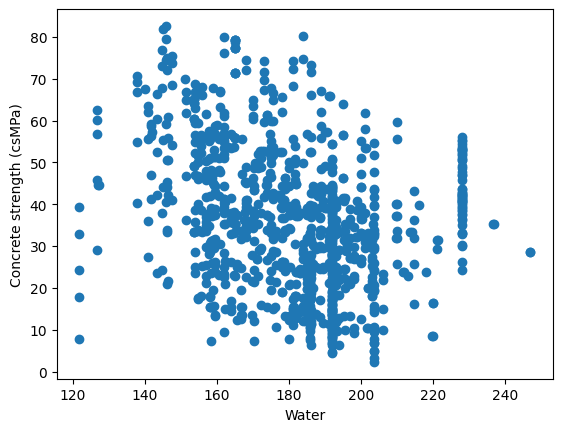

In [8]:
plt.scatter(df["water"], df["csMPa"])
plt.xlabel("Water")
plt.ylabel("Concrete strength (csMPa)")
plt.show()


### View the water distribution

Plot the water column with Matplotlib to check its distribution before considering transformations.


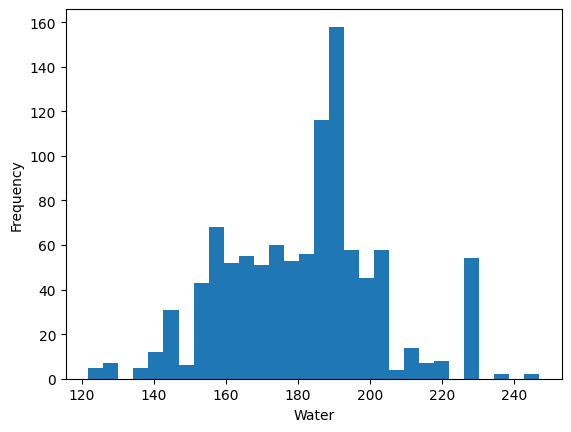

In [9]:
plt.hist(df["water"], bins=30)
plt.xlabel("Water")
plt.ylabel("Frequency")
plt.show()

### Check coarse aggregate normality

Use SciPy to create a Q-Q plot comparing coarse aggregate values against a normal distribution.


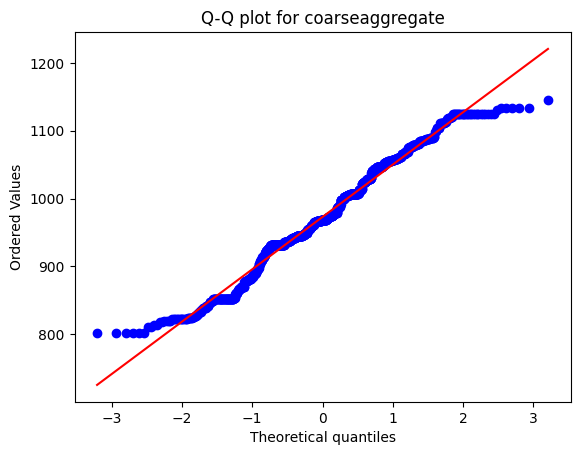

In [10]:
stats.probplot(df["coarseaggregate"], dist="norm", plot=plt)
plt.title("Q-Q plot for coarseaggregate")
plt.show()

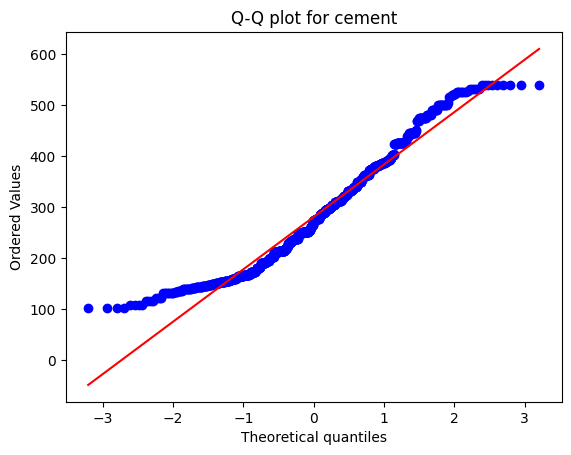

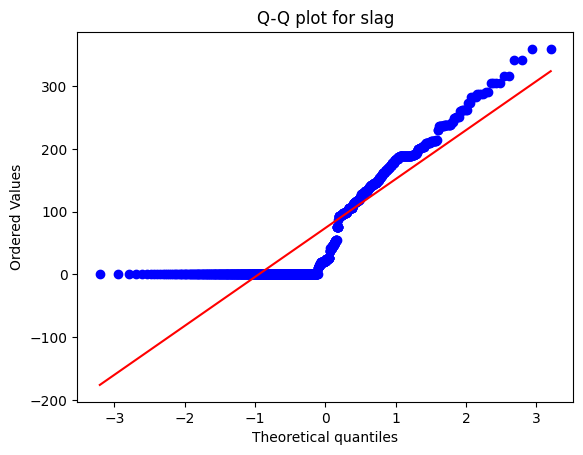

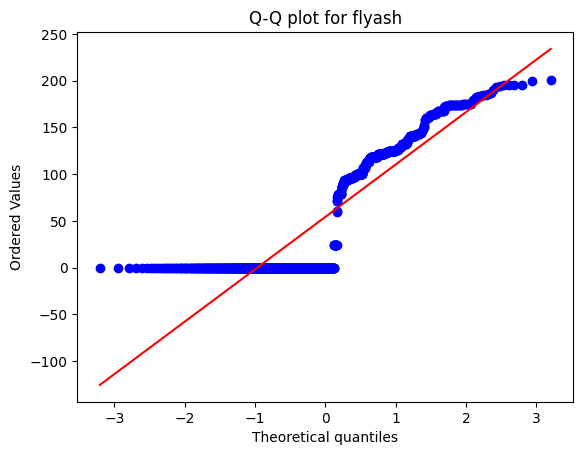

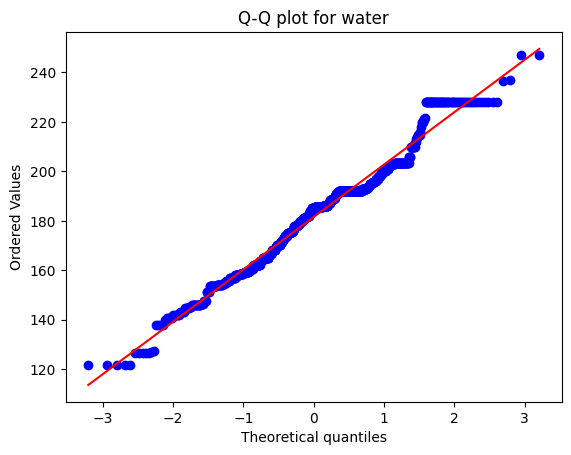

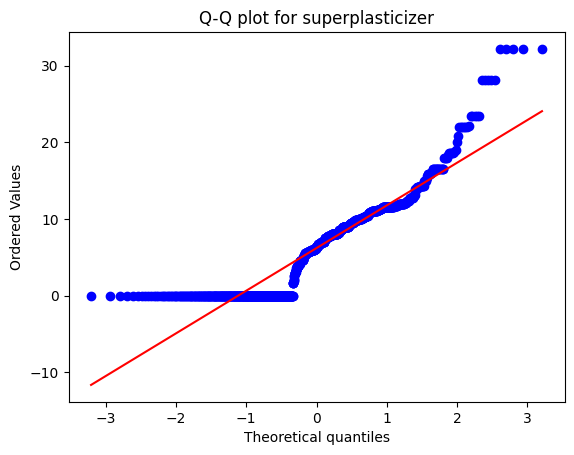

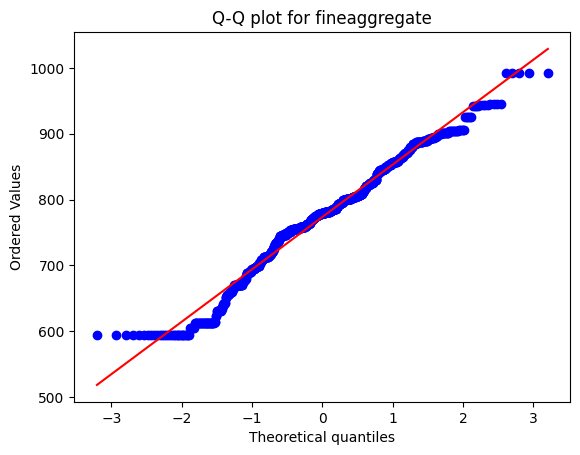

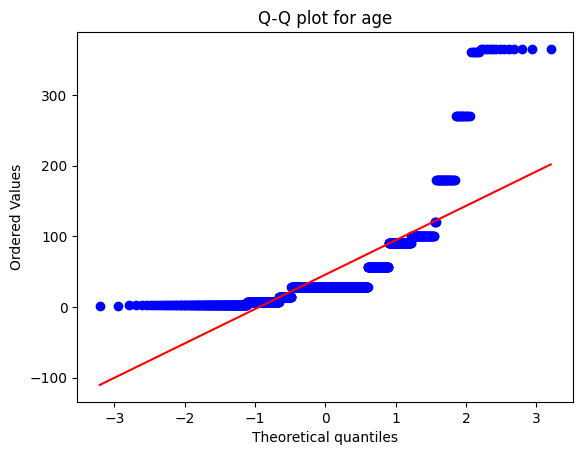

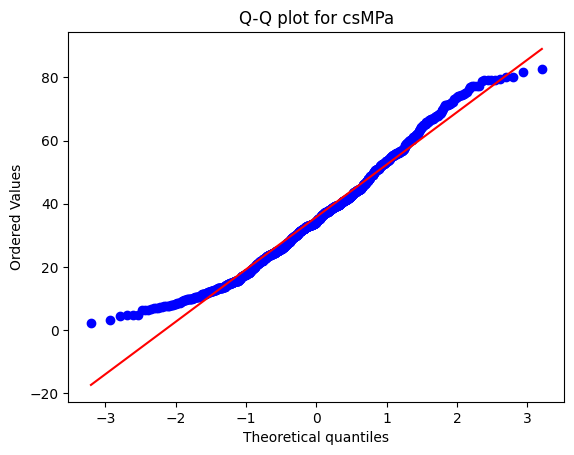

In [11]:
columns_with_qqplot = ["coarseaggregate"]
columns_without_qqplot = [column for column in df.columns if column not in columns_with_qqplot]

for column in columns_without_qqplot:
    plt.figure()
    stats.probplot(df[column], dist="norm", plot=plt)
    plt.title(f"Q-Q plot for {column}")
    plt.show()

### Feature scaling note

Scaling or transforming the numeric features can be tested later to see whether it improves linear regression performance.


### Create the model

Initialize a linear regression model for predicting concrete compressive strength.


In [12]:
model = LinearRegression()#creating the model

### Train the model

Fit the linear regression model using the training features and target values.


In [13]:
model.fit(X_train , Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Generate predictions

Predict concrete strength for the test features.


In [14]:
Y_pred = model.predict(X_test)

### Evaluate regression performance

Use regression metrics instead of classification accuracy because `csMPa` is a continuous value.


In [15]:
r2 = r2_score(Y_test, Y_pred)
mae = mean_absolute_error(Y_test, Y_pred)
rmse = root_mean_squared_error(Y_test, Y_pred)

print(f"the r2 score is: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")


the r2 score is: 0.5944
MAE: 8.2986
RMSE: 10.4762


In [16]:
lr = LinearRegression()
mean_accuracy = np.mean(cross_val_score(lr , x , y , cv = 10))
print("the cross value accuracy is:" , mean_accuracy)

the cross value accuracy is: 0.27820729160873814


In [17]:
#i will use yeo johnson transformation here